# Fine-Tuning RadiologyNET for Binary Necrosis Classification

Baseline notebook for transfer learning on hip X-rays.

Pipeline:
- load train/val data from CSV or class folders;
- convert grayscale X-ray to 3-channel tensor;
- load local RadiologyNET pretrained weights into a ResNet50-compatible backbone;
- replace the classification head with 2 classes;
- train in 2 stages: head-only, then fine-tuning;
- track validation loss, accuracy, ROC-AUC, F1, recall;
- save the best checkpoint.


In [1]:
# ruff: noqa: T201
from __future__ import annotations

import csv
import json
import math
import os
import random
import sys
from collections import Counter
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "tazotron").exists():
            return candidate
    msg = "Could not locate the repository root containing src/tazotron"
    raise RuntimeError(msg)


PROJECT_ROOT = _find_repo_root(Path.cwd().resolve())
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# Prevent ClearML SDK import from trying to talk to the default public server
# during local/offline notebook runs.
os.environ.setdefault("CLEARML_OFFLINE_MODE", "1")
os.environ.setdefault("CLEARML_NO_DEFAULT_SERVER", "1")

import matplotlib.pyplot as plt
import timm
import torch
from PIL import Image
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T
from tqdm.auto import tqdm

from tazotron.integrations.clearml import (
    CLEARML_ENABLED,
    finish_experiment,
    log_metrics,
    start_experiment,
    upload_model_artifact,
)


## Config

Edit only this cell first.

Default setup uses CSV manifests generated next to `.data/output_with_crop`.

`DATA_SOURCE_TYPE`:
- `"folders"` expects `TRAIN_DIR/class_name/*` and `VAL_DIR/class_name/*`
- `"csv"` expects separate train/val CSV files with columns `path,label`


In [2]:
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATA_SOURCE_TYPE = "csv"  # "folders" or "csv"
DATA_ROOT = PROJECT_ROOT / ".data" / "output_with_crop"

TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"

TRAIN_CSV_PATH = DATA_ROOT / "train.csv"
VAL_CSV_PATH = DATA_ROOT / "val.csv"
CSV_IMAGE_ROOT: Path | None = DATA_ROOT

CLASS_TO_LABEL = {"healthy": 0, "necrosis": 1}
NUM_CLASSES = 2

MODEL_NAME = "resnet50"
WEIGHTS_PATH = PROJECT_ROOT / ".data" / "weights" / "radiologynet_resnet50.pth"
OUTPUT_DIR = PROJECT_ROOT / "reports" / "models"
CHECKPOINT_NAME = "radiologynet_binary_necrosis_best.pt"

CLEARML_PROJECT_NAME = "Tazotron"
CLEARML_TASK_NAME = "radiologynet_binary_necrosis_baseline"
CLEARML_TAGS = ["radiologynet", "resnet50", "binary-necrosis", "xray"]
CLEARML_ENABLED = True

IMAGE_SIZE = 224
BATCH_SIZE = 16
NUM_WORKERS = 0
PIN_MEMORY = torch.cuda.is_available()

HEAD_EPOCHS = 3
FINETUNE_EPOCHS = 5
HEAD_LR = 1e-3
FINETUNE_LR = 1e-4
WEIGHT_DECAY = 1e-4
FINETUNE_UNFREEZE_MODE = "all"  # "all" or "layer4"
BEST_METRIC = "roc_auc"

TRAIN_HORIZONTAL_FLIP_P = 0.5
NORMALIZE_MEAN = [0.5, 0.5, 0.5]
NORMALIZE_STD = [0.5, 0.5, 0.5]

PREVIEW_BATCH = True
PREVIEW_ITEMS = 4

print("Project root:", PROJECT_ROOT)
print("Device:", DEVICE)
print("Data source:", DATA_SOURCE_TYPE)
print("Data root:", DATA_ROOT)
print("Train CSV:", TRAIN_CSV_PATH)
print("Val CSV:", VAL_CSV_PATH)
print("Weights path:", WEIGHTS_PATH)
print("ClearML enabled:", CLEARML_ENABLED)


Project root: /Users/mikhail_polevoda/Projects/tazotron
Device: cpu
Data source: csv
Data root: /Users/mikhail_polevoda/Projects/tazotron/.data/output_with_crop
Train CSV: /Users/mikhail_polevoda/Projects/tazotron/.data/output_with_crop/train.csv
Val CSV: /Users/mikhail_polevoda/Projects/tazotron/.data/output_with_crop/val.csv
Weights path: /Users/mikhail_polevoda/Projects/tazotron/.data/weights/radiologynet_resnet50.pth
ClearML enabled: False


## Data Loading

The notebook supports:
- standard image files (`png`, `jpg`, `jpeg`, `bmp`, `tif`, `tiff`);
- `.pt` tensors, which is useful for existing project-style X-ray artifacts.


In [3]:
SUPPORTED_SUFFIXES = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".pt"}
EPS = 1e-6


def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def parse_label(raw_label: str | int) -> int:
    if isinstance(raw_label, int):
        return raw_label
    label_text = str(raw_label).strip().lower()
    if label_text.isdigit():
        return int(label_text)
    if label_text not in CLASS_TO_LABEL:
        msg = f"Unknown label: {raw_label!r}. Expected one of {list(CLASS_TO_LABEL)} or an integer."
        raise ValueError(msg)
    return CLASS_TO_LABEL[label_text]


def resolve_csv_image_path(raw_path: str, csv_path: Path, image_root: Path | None) -> Path:
    path = Path(raw_path)
    if path.is_absolute():
        return path
    if image_root is not None:
        return (image_root / path).resolve()
    return (csv_path.parent / path).resolve()


def read_csv_records(csv_path: Path, image_root: Path | None = None) -> list[dict]:
    csv_path = Path(csv_path)
    if not csv_path.exists():
        raise FileNotFoundError(f"CSV file does not exist: {csv_path}")
    records: list[dict] = []
    with csv_path.open("r", newline="") as handle:
        reader = csv.DictReader(handle)
        fieldnames = set(reader.fieldnames or [])
        required = {"path", "label"}
        if not required.issubset(fieldnames):
            raise ValueError(f"{csv_path} must contain columns {required}, got {fieldnames}")
        for row_index, row in enumerate(reader, start=2):
            resolved_path = resolve_csv_image_path(row["path"], csv_path, image_root)
            if not resolved_path.exists():
                raise FileNotFoundError(
                    "CSV entry points to a missing file: "
                    f"{resolved_path} (from {csv_path}:{row_index}, raw path={row['path']!r})"
                )
            records.append(
                {
                    "path": resolved_path,
                    "label": parse_label(row["label"]),
                }
            )
    return records


def collect_folder_records(split_dir: Path, class_to_label: dict[str, int]) -> list[dict]:
    split_dir = Path(split_dir)
    if not split_dir.exists():
        raise FileNotFoundError(f"Directory does not exist: {split_dir}")
    records: list[dict] = []
    for class_name, label in class_to_label.items():
        class_dir = split_dir / class_name
        if not class_dir.is_dir():
            raise FileNotFoundError(f"Expected class directory: {class_dir}")
        for path in sorted(class_dir.rglob("*")):
            if path.is_file() and path.suffix.lower() in SUPPORTED_SUFFIXES:
                records.append({"path": path.resolve(), "label": label})
    return records


def load_records() -> tuple[list[dict], list[dict]]:
    if DATA_SOURCE_TYPE == "folders":
        return (
            collect_folder_records(TRAIN_DIR, CLASS_TO_LABEL),
            collect_folder_records(VAL_DIR, CLASS_TO_LABEL),
        )
    if DATA_SOURCE_TYPE == "csv":
        return (
            read_csv_records(TRAIN_CSV_PATH, CSV_IMAGE_ROOT),
            read_csv_records(VAL_CSV_PATH, CSV_IMAGE_ROOT),
        )
    raise ValueError(f"Unsupported DATA_SOURCE_TYPE: {DATA_SOURCE_TYPE}")


def summarize_records(records: list[dict], split_name: str) -> None:
    label_counts = Counter(record["label"] for record in records)
    print(
        f"{split_name}: {len(records)} samples | "
        + ", ".join(f"label {label} -> {count}" for label, count in sorted(label_counts.items()))
    )
    if records:
        print(f"{split_name} example path: {records[0]['path']}")


In [4]:
def squeeze_xray_tensor(tensor: torch.Tensor) -> torch.Tensor:
    tensor = tensor.detach().cpu().float()
    if tensor.ndim == 4 and tensor.shape[0] == 1 and tensor.shape[1] == 1:
        tensor = tensor[0, 0]
    elif tensor.ndim == 3 and tensor.shape[0] == 1:
        tensor = tensor[0]
    elif tensor.ndim == 3 and tensor.shape[-1] in (1, 3) and tensor.shape[0] not in (1, 3):
        tensor = tensor.permute(2, 0, 1)
        if tensor.shape[0] == 1:
            tensor = tensor[0]
        return tensor.float()
    return tensor.float()


def minmax_normalize(tensor: torch.Tensor) -> torch.Tensor:
    tensor = tensor.float()
    min_value = tensor.min()
    max_value = tensor.max()
    if float(max_value - min_value) < EPS:
        return torch.zeros_like(tensor, dtype=torch.float32)
    return (tensor - min_value) / (max_value - min_value)


def load_xray_tensor(path: Path) -> torch.Tensor:
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix not in SUPPORTED_SUFFIXES:
        raise ValueError(f"Unsupported file type: {path}")
    if suffix == ".pt":
        tensor = torch.load(path, map_location="cpu")
        if not isinstance(tensor, torch.Tensor):
            raise TypeError(f"Expected torch.Tensor inside {path}, got {type(tensor)}")
        tensor = squeeze_xray_tensor(tensor)
        if tensor.ndim == 2:
            tensor = tensor.unsqueeze(0)
        if tensor.ndim != 3 or tensor.shape[0] not in (1, 3):
            raise ValueError(f"Unsupported tensor shape for {path}: {tuple(tensor.shape)}")
        return minmax_normalize(tensor)
    with Image.open(path) as image:
        return minmax_normalize(T.ToTensor()(image.convert("L")))


def ensure_three_channels(image: torch.Tensor) -> torch.Tensor:
    if image.ndim == 2:
        image = image.unsqueeze(0)
    if image.ndim != 3:
        raise ValueError(f"Expected CHW tensor, got shape {tuple(image.shape)}")
    if image.shape[0] == 1:
        return image.repeat(3, 1, 1)
    if image.shape[0] == 3:
        return image
    raise ValueError(f"Expected 1 or 3 channels, got {image.shape[0]}")


class BinaryXrayDataset(Dataset):
    def __init__(self, records: list[dict], transform: T.Compose | None = None) -> None:
        self.records = list(records)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.records)

    def __getitem__(self, index: int) -> dict:
        record = self.records[index]
        image = load_xray_tensor(record["path"])
        if self.transform is not None:
            image = self.transform(image)
        return {
            "image": image,
            "label": torch.tensor(record["label"], dtype=torch.long),
            "path": str(record["path"]),
        }


def build_transforms(image_size: int) -> tuple[T.Compose, T.Compose]:
    train_transform = T.Compose(
        [
            T.Resize((image_size, image_size), antialias=True),
            T.RandomHorizontalFlip(p=TRAIN_HORIZONTAL_FLIP_P),
            T.Lambda(ensure_three_channels),
            T.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
        ]
    )
    eval_transform = T.Compose(
        [
            T.Resize((image_size, image_size), antialias=True),
            T.Lambda(ensure_three_channels),
            T.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
        ]
    )
    return train_transform, eval_transform


def resolve_num_workers(requested_num_workers: int) -> int:
    if requested_num_workers <= 0:
        return 0
    main_module = sys.modules.get("__main__")
    has_main_file = bool(getattr(main_module, "__file__", None))
    if "ipykernel" in sys.modules or not has_main_file:
        return 0
    return requested_num_workers


def build_loaders(
    train_records: list[dict],
    val_records: list[dict],
    *,
    num_workers: int | None = None,
) -> tuple[DataLoader, DataLoader]:
    worker_count = resolve_num_workers(NUM_WORKERS if num_workers is None else num_workers)
    train_transform, eval_transform = build_transforms(IMAGE_SIZE)
    train_dataset = BinaryXrayDataset(train_records, transform=train_transform)
    val_dataset = BinaryXrayDataset(val_records, transform=eval_transform)
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=worker_count,
        pin_memory=PIN_MEMORY,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=worker_count,
        pin_memory=PIN_MEMORY,
    )
    return train_loader, val_loader


def preview_batch(loader: DataLoader, max_items: int = 4) -> None:
    batch = next(iter(loader))
    images = batch["image"][:max_items]
    labels = batch["label"][:max_items]
    paths = batch["path"][:max_items]
    fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))
    if len(images) == 1:
        axes = [axes]
    for axis, image, label, path in zip(axes, images, labels, paths):
        display_image = image.detach().cpu().permute(1, 2, 0)
        display_image = (display_image * 0.5 + 0.5).clamp(0.0, 1.0)
        axis.imshow(display_image)
        axis.set_title(f"label={int(label)}\n{Path(path).name}")
        axis.axis("off")
    plt.tight_layout()
    plt.show()


## Backbone Initialization and RadiologyNET Weight Loading

Assumption for this baseline:
- `MODEL_NAME="resnet50"` is ResNet50-compatible with the local RadiologyNET checkpoint.
- if `WEIGHTS_PATH` exists, the notebook loads it into the backbone;
- if `WEIGHTS_PATH` is missing, the notebook falls back to random initialization.


In [5]:
KNOWN_PREFIXES = ("module.", "model.", "net.", "backbone.", "encoder.")
COMMON_STATE_DICT_KEYS = ("state_dict", "model_state_dict", "model", "net", "backbone")


def looks_like_state_dict(candidate: object) -> bool:
    return isinstance(candidate, dict) and bool(candidate) and all(
        isinstance(value, (torch.Tensor, nn.Parameter)) for value in candidate.values()
    )


def strip_known_prefixes(state_dict: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    cleaned: dict[str, torch.Tensor] = {}
    for key, value in state_dict.items():
        new_key = key
        changed = True
        while changed:
            changed = False
            for prefix in KNOWN_PREFIXES:
                if new_key.startswith(prefix):
                    new_key = new_key[len(prefix):]
                    changed = True
        cleaned[new_key] = value
    return cleaned


def extract_candidate_state_dicts(checkpoint: object) -> list[tuple[str, dict[str, torch.Tensor]]]:
    candidates: list[tuple[str, dict[str, torch.Tensor]]] = []
    if looks_like_state_dict(checkpoint):
        candidates.append(("checkpoint", checkpoint))
    if isinstance(checkpoint, dict):
        for key in COMMON_STATE_DICT_KEYS:
            value = checkpoint.get(key)
            if looks_like_state_dict(value):
                candidates.append((key, value))
    return candidates


def get_head_modules(model: nn.Module) -> list[nn.Module]:
    modules: list[nn.Module] = []
    for attribute in ("fc", "classifier", "head"):
        module = getattr(model, attribute, None)
        if isinstance(module, nn.Module):
            modules.append(module)
    if hasattr(model, "get_classifier"):
        classifier = model.get_classifier()
        if isinstance(classifier, nn.Module):
            modules.append(classifier)
    deduped: list[nn.Module] = []
    seen_ids: set[int] = set()
    for module in modules:
        module_id = id(module)
        if module_id not in seen_ids:
            deduped.append(module)
            seen_ids.add(module_id)
    if not deduped:
        raise ValueError("Could not locate classifier/head module on the model.")
    return deduped


def initialize_linear_layers(module: nn.Module) -> None:
    for child in module.modules():
        if isinstance(child, nn.Linear):
            nn.init.xavier_uniform_(child.weight)
            if child.bias is not None:
                nn.init.zeros_(child.bias)


def create_model_for_weight_loading(model_name: str) -> nn.Module:
    model = timm.create_model(model_name, pretrained=False)
    return model


def create_binary_model(model_name: str, num_classes: int) -> nn.Module:
    model = timm.create_model(model_name, pretrained=False)
    if not hasattr(model, "reset_classifier"):
        raise ValueError(f"{model_name} does not expose reset_classifier().")
    model.reset_classifier(num_classes=num_classes)
    for module in get_head_modules(model):
        initialize_linear_layers(module)
    return model


def load_radiologynet_weights(model: nn.Module, weights_path: Path | None) -> dict:
    if weights_path is None:
        print("RadiologyNET weights are not configured. Continuing with random initialization.")
        return {
            "loaded": False,
            "reason": "weights_path_is_none",
            "selected_state_dict": None,
            "matched_keys": 0,
            "missing_keys": [],
            "unexpected_keys": [],
        }

    weights_path = Path(weights_path)
    if not weights_path.exists():
        print(f"RadiologyNET weights not found at {weights_path}. Continuing with random initialization.")
        return {
            "loaded": False,
            "reason": "weights_file_missing",
            "selected_state_dict": None,
            "matched_keys": 0,
            "missing_keys": [],
            "unexpected_keys": [],
        }

    checkpoint = torch.load(weights_path, map_location="cpu")
    candidates = extract_candidate_state_dicts(checkpoint)
    if not candidates:
        raise ValueError(
            "Could not find a usable state_dict inside the checkpoint. "
            "Expected a flat state dict or a dict containing one of "
            f"{COMMON_STATE_DICT_KEYS}."
        )

    target_keys = set(model.state_dict().keys())
    best_name = ""
    best_state_dict: dict[str, torch.Tensor] | None = None
    best_overlap = -1

    for candidate_name, candidate_state_dict in candidates:
        normalized = strip_known_prefixes(candidate_state_dict)
        overlap = len(set(normalized.keys()) & target_keys)
        if overlap > best_overlap:
            best_name = candidate_name
            best_state_dict = normalized
            best_overlap = overlap

    if best_state_dict is None or best_overlap <= 0:
        raise ValueError(
            "None of the checkpoint state dicts match the selected backbone. "
            "Check MODEL_NAME and checkpoint format."
        )

    incompatible = model.load_state_dict(best_state_dict, strict=False)
    info = {
        "loaded": True,
        "reason": "loaded",
        "selected_state_dict": best_name,
        "matched_keys": best_overlap,
        "missing_keys": incompatible.missing_keys,
        "unexpected_keys": incompatible.unexpected_keys,
    }
    print(
        json.dumps(
            {
                "selected_state_dict": best_name,
                "matched_keys": best_overlap,
                "missing_keys_count": len(incompatible.missing_keys),
                "unexpected_keys_count": len(incompatible.unexpected_keys),
            },
            indent=2,
        )
    )
    if incompatible.missing_keys:
        print("Missing keys (first 20):", incompatible.missing_keys[:20])
    if incompatible.unexpected_keys:
        print("Unexpected keys (first 20):", incompatible.unexpected_keys[:20])
    return info


def initialize_radiologynet_binary_model(
    model_name: str,
    weights_path: Path | None,
    num_classes: int,
) -> tuple[nn.Module, dict]:
    model = create_model_for_weight_loading(model_name)
    load_info = load_radiologynet_weights(model, weights_path)
    model.reset_classifier(num_classes=num_classes)
    for module in get_head_modules(model):
        initialize_linear_layers(module)
    return model, load_info


def freeze_backbone(model: nn.Module) -> None:
    for parameter in model.parameters():
        parameter.requires_grad = False
    for module in get_head_modules(model):
        for parameter in module.parameters():
            parameter.requires_grad = True


def unfreeze_for_finetuning(model: nn.Module, mode: str = "all") -> None:
    if mode == "all":
        for parameter in model.parameters():
            parameter.requires_grad = True
        return
    if mode == "layer4":
        for parameter in model.parameters():
            parameter.requires_grad = False
        for module in get_head_modules(model):
            for parameter in module.parameters():
                parameter.requires_grad = True
        layer4 = getattr(model, "layer4", None)
        if layer4 is None:
            raise ValueError("layer4 unfreeze mode is only supported for ResNet-like models.")
        for parameter in layer4.parameters():
            parameter.requires_grad = True
        return
    raise ValueError(f"Unsupported fine-tuning mode: {mode}")


def count_parameters(model: nn.Module) -> tuple[int, int]:
    total = sum(parameter.numel() for parameter in model.parameters())
    trainable = sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return total, trainable


## Metrics and Training Loops

`scikit-learn` is not used here.
ROC-AUC is computed directly from prediction scores.


In [6]:
def safe_divide(numerator: float, denominator: float) -> float:
    return float(numerator) / float(denominator) if denominator else 0.0


def binary_roc_auc(targets: list[int], scores: list[float]) -> float:
    targets_tensor = torch.as_tensor(targets, dtype=torch.long)
    scores_tensor = torch.as_tensor(scores, dtype=torch.float32)
    positive_mask = targets_tensor == 1
    negative_mask = targets_tensor == 0
    n_positive = int(positive_mask.sum().item())
    n_negative = int(negative_mask.sum().item())
    if n_positive == 0 or n_negative == 0:
        return float("nan")

    order = torch.argsort(scores_tensor)
    sorted_scores = scores_tensor[order]
    ranks = torch.zeros_like(scores_tensor, dtype=torch.float32)

    start = 0
    current_rank = 1.0
    while start < len(sorted_scores):
        end = start
        while end + 1 < len(sorted_scores) and torch.isclose(
            sorted_scores[end + 1], sorted_scores[start]
        ).item():
            end += 1
        average_rank = (current_rank + current_rank + (end - start)) / 2.0
        ranks[order[start : end + 1]] = average_rank
        current_rank += end - start + 1
        start = end + 1

    positive_rank_sum = float(ranks[positive_mask].sum().item())
    return (positive_rank_sum - n_positive * (n_positive + 1) / 2.0) / (n_positive * n_negative)


def compute_binary_metrics(targets: list[int], scores: list[float], *, loss: float) -> dict[str, float]:
    targets_tensor = torch.as_tensor(targets, dtype=torch.long)
    scores_tensor = torch.as_tensor(scores, dtype=torch.float32)
    predictions = (scores_tensor >= 0.5).long()

    tp = int(((predictions == 1) & (targets_tensor == 1)).sum().item())
    tn = int(((predictions == 0) & (targets_tensor == 0)).sum().item())
    fp = int(((predictions == 1) & (targets_tensor == 0)).sum().item())
    fn = int(((predictions == 0) & (targets_tensor == 1)).sum().item())

    accuracy = safe_divide(tp + tn, len(targets))
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)
    f1 = safe_divide(2 * precision * recall, precision + recall)
    roc_auc = binary_roc_auc(targets, scores)

    return {
        "loss": float(loss),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(roc_auc),
    }


def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device,
) -> dict[str, float]:
    model.train()
    total_loss = 0.0
    total_items = 0
    all_targets: list[int] = []
    all_scores: list[float] = []

    for batch in tqdm(loader, desc="train", leave=False):
        inputs = batch["image"].to(device)
        targets = batch["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        probabilities = torch.softmax(outputs, dim=1)[:, 1]
        batch_size = inputs.size(0)
        total_loss += float(loss.item()) * batch_size
        total_items += batch_size
        all_targets.extend(targets.detach().cpu().tolist())
        all_scores.extend(probabilities.detach().cpu().tolist())

    average_loss = total_loss / max(1, total_items)
    return compute_binary_metrics(all_targets, all_scores, loss=average_loss)


def evaluate(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    *,
    desc: str,
) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    total_items = 0
    all_targets: list[int] = []
    all_scores: list[float] = []

    with torch.no_grad():
        for batch in tqdm(loader, desc=desc, leave=False):
            inputs = batch["image"].to(device)
            targets = batch["label"].to(device)

            outputs = model(inputs)
            loss = criterion(outputs, targets)
            probabilities = torch.softmax(outputs, dim=1)[:, 1]

            batch_size = inputs.size(0)
            total_loss += float(loss.item()) * batch_size
            total_items += batch_size
            all_targets.extend(targets.detach().cpu().tolist())
            all_scores.extend(probabilities.detach().cpu().tolist())

    average_loss = total_loss / max(1, total_items)
    return compute_binary_metrics(all_targets, all_scores, loss=average_loss)


def metric_for_selection(metrics: dict[str, float], metric_name: str) -> float:
    value = float(metrics[metric_name])
    return value if math.isfinite(value) else float("-inf")


def save_best_checkpoint(
    checkpoint_path: Path,
    model: nn.Module,
    *,
    config_snapshot: dict,
    epoch: int,
    stage: str,
    val_metrics: dict[str, float],
) -> None:
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "config": config_snapshot,
            "epoch": epoch,
            "stage": stage,
            "val_metrics": val_metrics,
        },
        checkpoint_path,
    )


## Run the Experiment

This cell:
- loads train/val records;
- builds dataloaders;
- initializes the RadiologyNET-backed model;
- trains the head;
- fine-tunes the backbone;
- saves the best checkpoint.


train: 756 samples | label 0 -> 378, label 1 -> 378
train example path: /Users/mikhail_polevoda/Projects/tazotron/.data/output_with_crop/without_necro/s0006.pt
val: 188 samples | label 0 -> 94, label 1 -> 94
val example path: /Users/mikhail_polevoda/Projects/tazotron/.data/output_with_crop/without_necro/s0011.pt


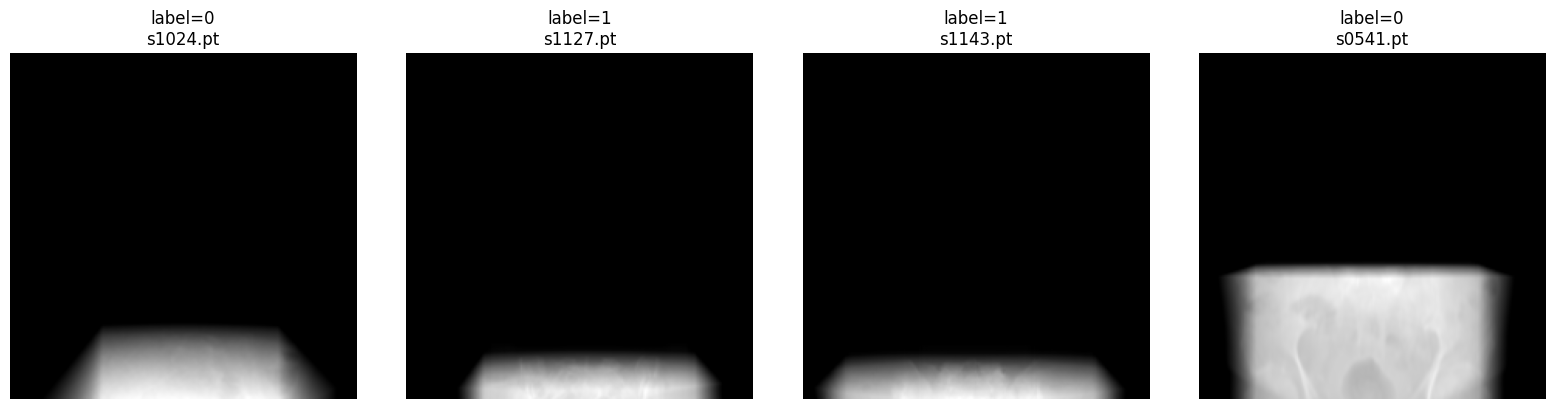

RadiologyNET weights not found at /Users/mikhail_polevoda/Projects/tazotron/.data/weights/radiologynet_resnet50.pth. Continuing with random initialization.

Stage: head | trainable params: 4,098/23,512,130 | lr=0.001


train:   0%|          | 0/48 [00:00<?, ?it/s]

val-head:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 01 | stage=head | train_loss=0.7802 | val_loss=0.7367 | val_acc=0.5000 | val_auc=0.5007 | val_f1=0.0000 | val_recall=0.0000
Saved new best checkpoint -> /Users/mikhail_polevoda/Projects/tazotron/reports/models/radiologynet_binary_necrosis_best.pt


train:   0%|          | 0/48 [00:00<?, ?it/s]

...

val-finetune:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 07 | stage=finetune | train_loss=0.7342 | val_loss=0.7381 | val_acc=0.4947 | val_auc=0.4978 | val_f1=0.3709 | val_recall=0.2979


train:   0%|          | 0/48 [00:00<?, ?it/s]

val-finetune:   0%|          | 0/12 [00:00<?, ?it/s]

Epoch 08 | stage=finetune | train_loss=0.7223 | val_loss=0.7031 | val_acc=0.5000 | val_auc=0.5010 | val_f1=0.3286 | val_recall=0.2447

Best validation metrics:
{
  "loss": 0.6954781438441987,
  "accuracy": 0.5053191489361702,
  "precision": 0.5034965034965035,
  "recall": 0.7659574468085106,
  "f1": 0.6075949367088609,
  "roc_auc": 0.5021502942507922
}
Best checkpoint: /Users/mikhail_polevoda/Projects/tazotron/reports/models/radiologynet_binary_necrosis_best.pt


In [7]:
set_seed(SEED)
device = torch.device(DEVICE)

train_records, val_records = load_records()
summarize_records(train_records, "train")
summarize_records(val_records, "val")

if not train_records:
    raise ValueError("Training split is empty.")
if not val_records:
    raise ValueError("Validation split is empty.")

effective_num_workers = resolve_num_workers(NUM_WORKERS)
if effective_num_workers != NUM_WORKERS:
    print(
        f"Overriding NUM_WORKERS from {NUM_WORKERS} to {effective_num_workers} "
        "inside the notebook to avoid DataLoader multiprocessing pickling issues."
    )

train_loader, val_loader = build_loaders(train_records, val_records, num_workers=effective_num_workers)

if PREVIEW_BATCH:
    preview_batch(train_loader, max_items=PREVIEW_ITEMS)

model, weight_load_info = initialize_radiologynet_binary_model(
    MODEL_NAME,
    WEIGHTS_PATH,
    NUM_CLASSES,
)
model = model.to(device)
criterion = nn.CrossEntropyLoss()

config_snapshot = {
    "seed": SEED,
    "device": DEVICE,
    "data_source_type": DATA_SOURCE_TYPE,
    "train_dir": str(TRAIN_DIR),
    "val_dir": str(VAL_DIR),
    "train_csv_path": str(TRAIN_CSV_PATH),
    "val_csv_path": str(VAL_CSV_PATH),
    "csv_image_root": None if CSV_IMAGE_ROOT is None else str(CSV_IMAGE_ROOT),
    "class_to_label": CLASS_TO_LABEL,
    "num_classes": NUM_CLASSES,
    "model_name": MODEL_NAME,
    "weights_path": str(WEIGHTS_PATH),
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "num_workers": effective_num_workers,
    "head_epochs": HEAD_EPOCHS,
    "finetune_epochs": FINETUNE_EPOCHS,
    "head_lr": HEAD_LR,
    "finetune_lr": FINETUNE_LR,
    "weight_decay": WEIGHT_DECAY,
    "finetune_unfreeze_mode": FINETUNE_UNFREEZE_MODE,
    "best_metric": BEST_METRIC,
    "train_horizontal_flip_p": TRAIN_HORIZONTAL_FLIP_P,
    "weight_load_info": weight_load_info,
}

run = start_experiment(
    config=config_snapshot,
    task_name=CLEARML_TASK_NAME,
    project_name=CLEARML_PROJECT_NAME,
    tags=CLEARML_TAGS,
    enabled=CLEARML_ENABLED,
)

checkpoint_path = OUTPUT_DIR / CHECKPOINT_NAME
history: list[dict] = []
best_metric_value = float("-inf")
best_val_metrics: dict[str, float] | None = None

stages = [
    {"name": "head", "epochs": HEAD_EPOCHS, "lr": HEAD_LR},
    {"name": "finetune", "epochs": FINETUNE_EPOCHS, "lr": FINETUNE_LR},
]

global_epoch = 0
for stage in stages:
    if stage["epochs"] <= 0:
        continue

    if stage["name"] == "head":
        freeze_backbone(model)
    else:
        unfreeze_for_finetuning(model, FINETUNE_UNFREEZE_MODE)

    total_params, trainable_params = count_parameters(model)
    print(
        f"\nStage: {stage['name']} | "
        f"trainable params: {trainable_params:,}/{total_params:,} | "
        f"lr={stage['lr']}"
    )

    optimizer = torch.optim.AdamW(
        [parameter for parameter in model.parameters() if parameter.requires_grad],
        lr=stage["lr"],
        weight_decay=WEIGHT_DECAY,
    )

    for local_epoch in range(1, stage["epochs"] + 1):
        global_epoch += 1

        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_metrics = evaluate(model, val_loader, criterion, device, desc=f"val-{stage['name']}")

        row = {
            "epoch": global_epoch,
            "stage": stage["name"],
            **{f"train_{key}": value for key, value in train_metrics.items()},
            **{f"val_{key}": value for key, value in val_metrics.items()},
        }
        history.append(row)

        log_metrics(
            run,
            train_metrics,
            split="train",
            iteration=global_epoch,
            enabled=CLEARML_ENABLED,
        )
        log_metrics(
            run,
            val_metrics,
            split="val",
            iteration=global_epoch,
            enabled=CLEARML_ENABLED,
        )

        print(
            f"Epoch {global_epoch:02d} | "
            f"stage={stage['name']} | "
            f"train_loss={train_metrics['loss']:.4f} | "
            f"val_loss={val_metrics['loss']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"val_auc={val_metrics['roc_auc']:.4f} | "
            f"val_f1={val_metrics['f1']:.4f} | "
            f"val_recall={val_metrics['recall']:.4f}"
        )

        current_metric_value = metric_for_selection(val_metrics, BEST_METRIC)
        if current_metric_value > best_metric_value:
            best_metric_value = current_metric_value
            best_val_metrics = val_metrics
            save_best_checkpoint(
                checkpoint_path,
                model,
                config_snapshot=config_snapshot,
                epoch=global_epoch,
                stage=stage["name"],
                val_metrics=val_metrics,
            )
            print(f"Saved new best checkpoint -> {checkpoint_path}")

if best_val_metrics is None:
    raise RuntimeError("Training finished without a valid checkpoint.")

print("\nBest validation metrics:")
print(json.dumps(best_val_metrics, indent=2))
print("Best checkpoint:", checkpoint_path)


## Reload Best Checkpoint and Plot Curves

Final sanity check:
- reload the best saved model;
- evaluate it again on the validation split;
- plot training curves.


best-val:   0%|          | 0/12 [00:00<?, ?it/s]

Reloaded checkpoint metrics:
{
  "loss": 0.6954781438441987,
  "accuracy": 0.5053191489361702,
  "precision": 0.5034965034965035,
  "recall": 0.7659574468085106,
  "f1": 0.6075949367088609,
  "roc_auc": 0.5021502942507922
}


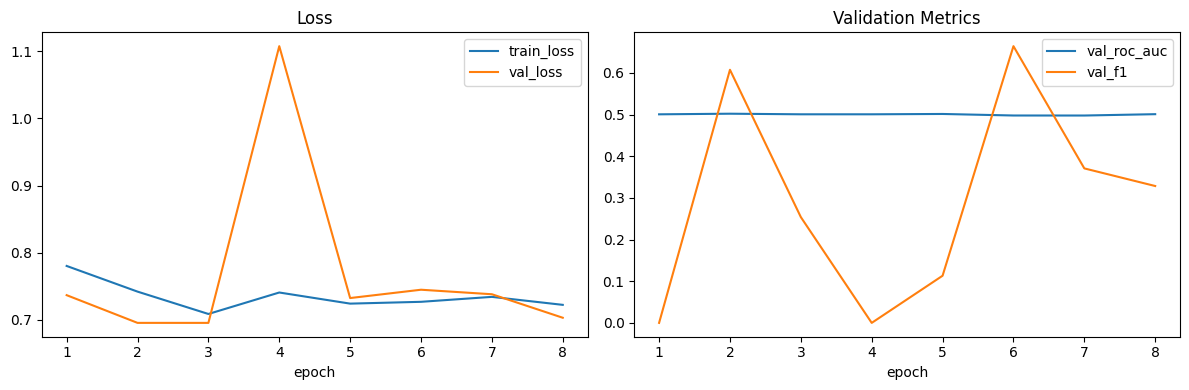

In [8]:
best_checkpoint = torch.load(checkpoint_path, map_location="cpu")
best_model = create_binary_model(MODEL_NAME, NUM_CLASSES).to(device)
best_model.load_state_dict(best_checkpoint["model_state_dict"])

reloaded_val_metrics = evaluate(best_model, val_loader, criterion, device, desc="best-val")
print("Reloaded checkpoint metrics:")
print(json.dumps(reloaded_val_metrics, indent=2))

log_metrics(
    run,
    best_checkpoint["val_metrics"],
    split="best_val",
    iteration=int(best_checkpoint["epoch"]),
    enabled=CLEARML_ENABLED,
)
log_metrics(
    run,
    reloaded_val_metrics,
    split="best_val_reloaded",
    iteration=int(best_checkpoint["epoch"]),
    enabled=CLEARML_ENABLED,
)

if checkpoint_path.exists():
    upload_model_artifact(
        run,
        alias="best_model_state_dict",
        path=checkpoint_path,
        enabled=CLEARML_ENABLED,
    )

epochs = [row["epoch"] for row in history]
train_losses = [row["train_loss"] for row in history]
val_losses = [row["val_loss"] for row in history]
val_aucs = [row["val_roc_auc"] for row in history]
val_f1s = [row["val_f1"] for row in history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, train_losses, label="train_loss")
axes[0].plot(epochs, val_losses, label="val_loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(epochs, val_aucs, label="val_roc_auc")
axes[1].plot(epochs, val_f1s, label="val_f1")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

finish_experiment(run, enabled=CLEARML_ENABLED)
